# Student Dropout EDA & Visualizations

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("G:/Python Projects/Edtech_student_dropout_analysis/data/student_dropout_dataset.csv")

In [3]:
print("Dataset loaded successfully!")
# Display the first few rows of the dataset
print(df.head())

Dataset loaded successfully!
  student_id  age      region enroll_date  exam_season  courses_enrolled  \
0   STU00001   26  Alexandria  2024-01-13            0                 3   
1   STU00002   23       Amman  2024-05-05            0                 6   
2   STU00003   17       Dubai  2024-03-12            0                 3   
3   STU00004   23  Alexandria  2024-12-12            0                 6   
4   STU00005   20     Baghdad  2024-02-14            0                 5   

   completed_assignments  completion_rate  login_frequency  \
0                      5           0.3571             5.29   
1                      0           0.0000             0.84   
2                      1           0.0435             1.79   
3                     13           0.4396             0.78   
4                      5           0.2078             0.92   

   last_activity_days_ago  forum_posts_count  dropout_score  label  \
0                      10                  5         0.1064      0   
1

In [4]:
# Display basic information about the dataset
print("\nDataset Information:")
print(df.info())


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   student_id              5000 non-null   str    
 1   age                     5000 non-null   int64  
 2   region                  5000 non-null   str    
 3   enroll_date             5000 non-null   str    
 4   exam_season             5000 non-null   int64  
 5   courses_enrolled        5000 non-null   int64  
 6   completed_assignments   5000 non-null   int64  
 7   completion_rate         5000 non-null   float64
 8   login_frequency         5000 non-null   float64
 9   last_activity_days_ago  5000 non-null   int64  
 10  forum_posts_count       5000 non-null   int64  
 11  dropout_score           5000 non-null   float64
 12  label                   5000 non-null   int64  
 13  label_multiclass        5000 non-null   int64  
 14  label_name              5000 

In [5]:
# Checking no of rows and columns
print("\nDataset Shape:")   
print(df.shape)


Dataset Shape:
(5000, 15)


In [6]:
print(f"\nLabel distribution:\n{df['label_name'].value_counts()}")


Label distribution:
label_name
active     1704
at-risk    1663
dropped    1633
Name: count, dtype: int64


In [7]:
# Set visual style for all charts
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [10]:
# Count how many students in each status
counts = df['label_name'].value_counts()
print("\nStudent Status Counts:")
print(counts)


Student Status Counts:
label_name
active     1704
at-risk    1663
dropped    1633
Name: count, dtype: int64


## EdTech Student Dropout Analysis
### Python EDA
**Dataset:** 5,000 students | 15 features | 0 missing values  
**Goal:** Understand why 33% of students drop out

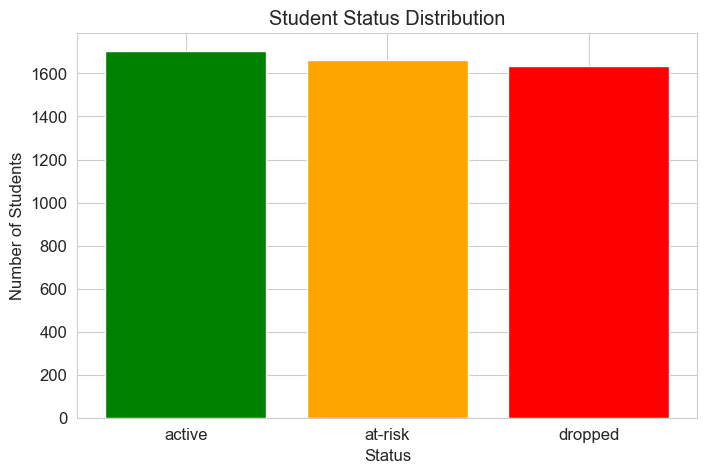

In [11]:
# Chart 1: Dropout Distribution

# Draw bar chart
plt.figure(figsize=(8, 5))
plt.bar(counts.index, counts.values, color=['green', 'orange', 'red'])
plt.title('Student Status Distribution')
plt.xlabel('Status')
plt.ylabel('Number of Students')
plt.savefig('01_dropout_distribution.png')
plt.show()

### Finding 1: Login Frequency is the Strongest Dropout Signal
Active students login 6.67x/week vs dropped students at 0.86x/week.
That's an 87% decline — the clearest early warning signal in the data.

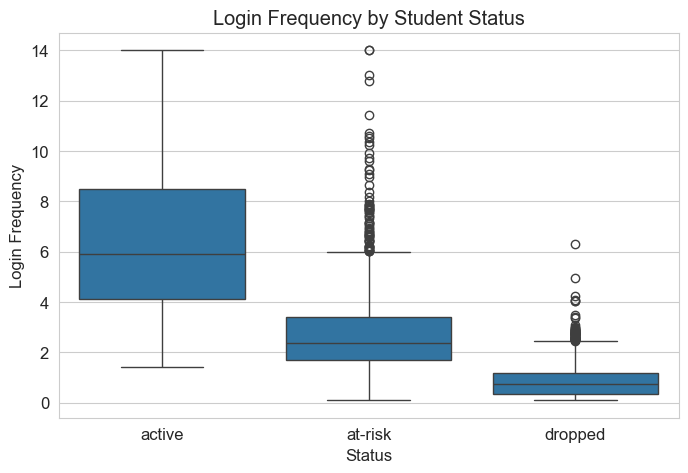

In [12]:
# Chart 2: Login Frequency vs Status

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='label_name', y='login_frequency',
            order=['active', 'at-risk', 'dropped'])
plt.title('Login Frequency by Student Status')
plt.xlabel('Status')
plt.ylabel('Login Frequency')
plt.savefig('02_login_frequency.png')
plt.show()

### Finding 2: Completion Rate Collapses Before Dropout
Dropped students complete only 9% of coursework vs 51% for active students.
Combined with low login frequency, this forms the dropout fingerprint.

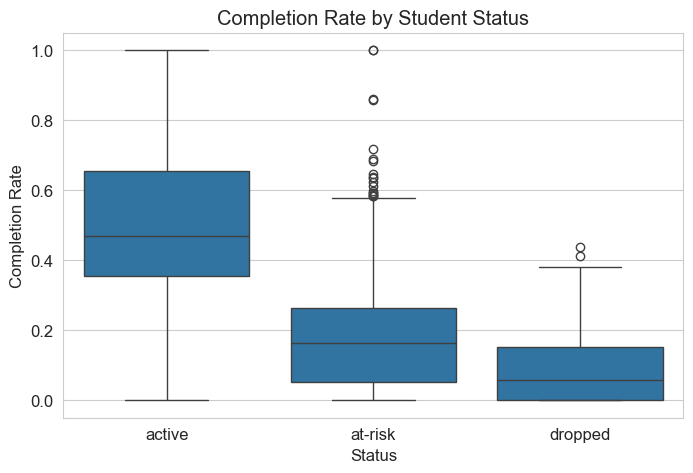

In [13]:
# Chart 3: Completion Rate vs Status
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='label_name', y='completion_rate',
            order=['active', 'at-risk', 'dropped'])
plt.title('Completion Rate by Student Status')
plt.xlabel('Status')
plt.ylabel('Completion Rate')
plt.savefig('03_completion_rate.png')
plt.show()

In [14]:
# Extract year-month from enroll_date
df['enroll_month'] = pd.to_datetime(df['enroll_date']).dt.to_period('M')

# Count dropouts per month
monthly = df[df['label_name'] == 'dropped'].groupby('enroll_month').size()

### Finding 3: Dropout is Seasonal and Predictable
October (169 dropouts) and April (151 dropouts) spike every year.
These coincide with semester exam periods — predictable and preventable.

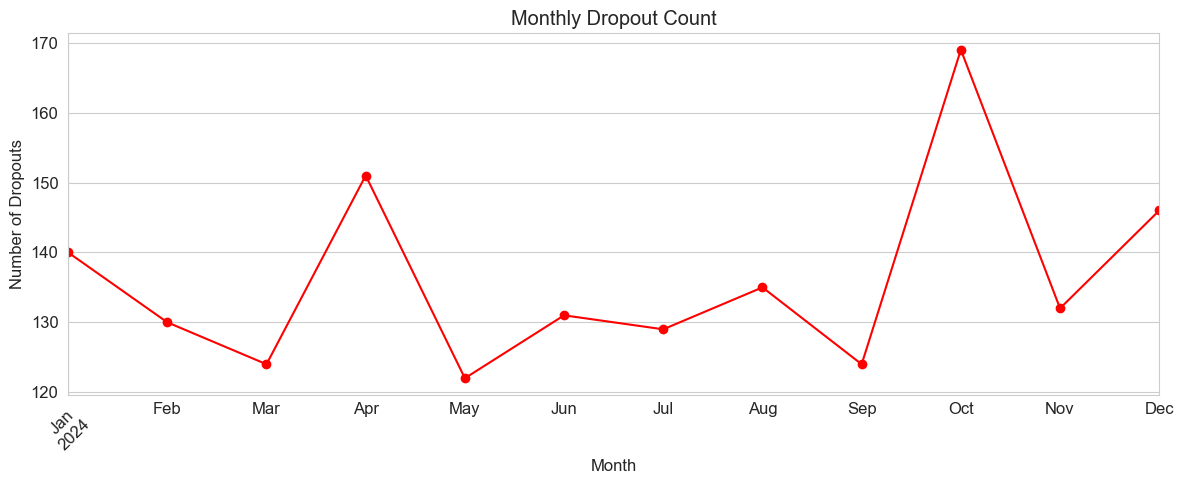

In [15]:
# Chart 4: Monthly Dropout Trend

# Draw line chart
plt.figure(figsize=(12, 5))
monthly.plot(kind='line', marker='o', color='red')
plt.title('Monthly Dropout Count')
plt.xlabel('Month')
plt.ylabel('Number of Dropouts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('04_monthly_trend.png')
plt.show()

In [16]:
# Chart 5: Regional Dropout Rate
# Calculate dropout rate per region
regional = df.groupby('region')['label_name'].apply(
    lambda x: (x == 'dropped').sum() / len(x) * 100
).reset_index()
regional.columns = ['region', 'dropout_rate']
regional = regional.sort_values('dropout_rate')


### Finding 4: Platform-Wide Problem, Not Regional
Only 7% spread across all regions (29-36%).
This confirms the issue is platform engagement, not geography.

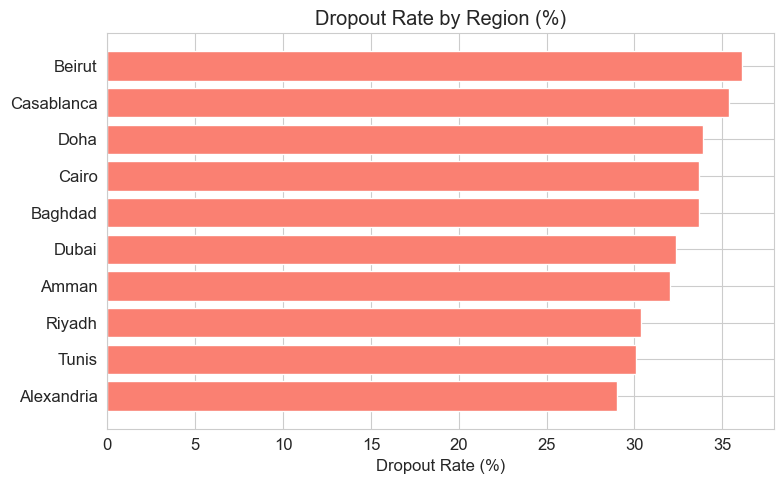

In [17]:
# Draw horizontal bar chart
plt.figure(figsize=(8, 5))
plt.barh(regional['region'], regional['dropout_rate'], color='salmon')
plt.title('Dropout Rate by Region (%)')
plt.xlabel('Dropout Rate (%)')
plt.tight_layout()
plt.savefig('05_regional_dropout.png')
plt.show()

### Finding 5: Strongest Predictors of Dropout
Correlation heatmap reveals login_frequency (-0.71) and 
completion_rate (-0.73) are the strongest dropout predictors.
Surprisingly, last_activity_days_ago shows weak correlation (0.09).

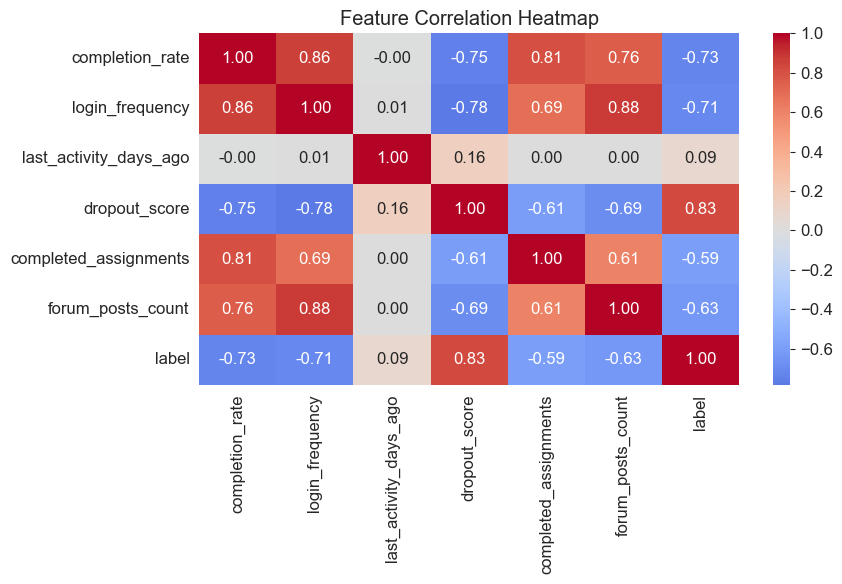

In [18]:
# Chart 6: Correlation Heatmap

# Select only number columns
numeric_cols = ['completion_rate', 'login_frequency',
                'last_activity_days_ago', 'dropout_score',
                'completed_assignments', 'forum_posts_count', 'label']

# Calculate correlations
corr = df[numeric_cols].corr()

# Draw heatmap
plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('06_correlation_heatmap.png')
plt.show()

## Summary
SQL + Python EDA confirms: dropout is predictable, seasonal, and 
driven primarily by engagement metrics (logins + completion rate).

**Next Steps:** Classification model to predict at-risk students